In [1]:
from typing import TypedDict,  Annotated, Literal
from pydantic import BaseModel, Field 
from langgraph.types import interrupt, Command
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END 
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
def reduce_workout_data(existing_list: list[dict], new_list: list[dict]) -> list[dict]:
    if not existing_list:
        existing_list = []
    if not new_list:
        new_list = []

    merged = {ex["exercise_name"].lower(): ex for ex in existing_list}
    for ex in new_list:
        merged[ex["exercise_name"].lower()] = ex 

    return list(merged.values())

In [3]:
class Exercise(BaseModel):
    exercise_name: str = Field(description="Name of the exercise (e.g., Squats, Deadlift)")
    weight_kg: int = Field(description="Weight lifted in kilograms")
    sets: int = Field(description="Number of sets completed")
    reps: int = Field(description="Number of reps per set")

class WorkoutLog(BaseModel):
    exercises: list[Exercise]

class State(TypedDict):
    user_input : str
    workout_data : Annotated[list[dict], reduce_workout_data]
    validation_error: str 
    human_correction : str 

llm = ChatOllama(model="llama3.1")
structured_llm = llm.with_structured_output(WorkoutLog)

In [4]:
def extract_node(state: State) -> State:
    prompt = f"Extract the workout data from this log: {state['user_input']}"
    result = structured_llm.invoke(prompt)
    exercise_list = [ex.model_dump() for ex in result.exercises]
    return {"workout_data" : exercise_list, "validation_error": ""}

In [5]:
def validate_node(state: State) -> State:
    errors = []
    for ex in state.get("workout_data", []):
        if ex["weight_kg"] > 500:
            errors.append(f"Suspicious weight for {ex['exercise_name']}: {ex['weight_kg']}kg")
    if errors:
        return {"validation_error" : " | ".join(errors)}
    return {"validation_error" : ""}

In [6]:
def ask_node(state: State) -> State:
    workout_str = "\n".join([
        f"- {ex['exercise_name'].title()}: {ex['weight_kg']}kg, {ex['sets']} sets of {ex['reps']}" 
        for ex in state.get("workout_data", [])
    ])
    error_msg = f"\n⚠️ SYSTEM WARNING: {state['validation_error']}\n" if state.get("validation_error") else ""
    decision = interrupt({
        "type" : "review", 
        "message": f"Current Workout Log:{error_msg}\n{workout_str}\n\nType 'approve' to save, or provide a natural language correction.",
    })
    return {"human_correction" : decision.get('reply', "approve")}

In [7]:
def apply_correction_node(state: State) -> State:
    return {"user_input" : state.get("human_correction", "")}

def route_approval(state: State) -> str:
    reply = state.get("human_correction", "approve").strip().lower()
    if reply == "approve":
        return END 
    else:
        return "apply_correction"

In [8]:
builder = StateGraph(State)
checkpointer = InMemorySaver()

builder.add_node("extract", extract_node)
builder.add_node("validate", validate_node)
builder.add_node("ask", ask_node)
builder.add_node("apply_correction", apply_correction_node)

builder.add_edge(START, "extract")
builder.add_edge("extract", "validate")
builder.add_edge("validate", "ask")

builder.add_conditional_edges("ask", route_approval, {
    END: END,
    "apply_correction": "apply_correction"
})

builder.add_edge("apply_correction", "extract")
graph = builder.compile(checkpointer=checkpointer)

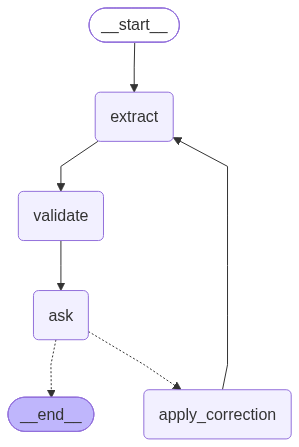

In [9]:
graph

In [12]:
config = {"configurable" : {"thread_id" : "workout_session_1"}}
user_input = "I hit squats 105kg for 3 sets of 4 reps, deadlift 135kg for 2 sets of 3, and leg press 600kg for 3 sets of 8."

print("--- STARTING GRAPH ---")
for event in graph.stream({"user_input" : user_input}, config=config, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"Executed Node: '{node_name}'")
        # print(f"State updated: '{state_update}'")

current_state = graph.get_state(config)
if current_state.next:
    print(f"\n⏸️ GRAPH PAUSED AT NODE: {current_state.next[0]}")
    interrupt_payload = current_state.tasks[0].interrupts[0].value
    print(f"\n{interrupt_payload['message']}")
    print("-----------------------------\n")
    human_reply = "Wait, my leg press was only 200kg. Also, add bench press 75 kg for 3 sets of 4 reps." 
    print(f"Human inputs: '{human_reply}'")

    print("\n--- RESUMING GRAPH ---")
    resume_data = {"reply" : human_reply}
    for event in graph.stream(Command(resume=resume_data), config=config, stream_mode="updates"):
        for node_name, state_update in event.items():
            print(f"Executed Node: '{node_name}'")

current_state = graph.get_state(config)
if current_state.next:
    interrupt_payload = current_state.tasks[0].interrupts[0].value
    print(f"\n{interrupt_payload['message']}")
    print("-----------------------------\n")
    
    # 5. Final approval
    print("Human inputs: 'approve'")
    print("\n--- FINALIZING GRAPH ---")
    for event in graph.stream(Command(resume={"reply": "approve"}), config=config):
        pass

print("\n✅ Workout Saved Successfully!")



--- STARTING GRAPH ---
Executed Node: 'extract'
Executed Node: 'validate'
Executed Node: '__interrupt__'

⏸️ GRAPH PAUSED AT NODE: ask

Current Workout Log:
⚠️ SYSTEM WARNING: Suspicious weight for leg press: 600kg

- Squats: 105kg, 3 sets of 4
- Deadlift: 135kg, 2 sets of 3
- Leg Press: 600kg, 3 sets of 8
- Bench Press: 75kg, 3 sets of 4

Type 'approve' to save, or provide a natural language correction.
-----------------------------

Human inputs: 'Wait, my leg press was only 200kg. Also, add bench press 75 kg for 3 sets of 4 reps.'

--- RESUMING GRAPH ---
Executed Node: 'ask'
Executed Node: 'apply_correction'
Executed Node: 'extract'
Executed Node: 'validate'
Executed Node: '__interrupt__'

Current Workout Log:
- Squats: 105kg, 3 sets of 4
- Deadlift: 135kg, 2 sets of 3
- Leg Press: 200kg, 1 sets of 0
- Bench Press: 75kg, 3 sets of 4

Type 'approve' to save, or provide a natural language correction.
-----------------------------

Human inputs: 'approve'

--- FINALIZING GRAPH ---

✅ W

In [15]:
config = {"configurable" : {"thread_id" : "workout_session_1"}}
user_input = "I hit squats 105kg for 3 sets of 4 reps, deadlift 135kg for 2 sets of 3, and leg press 600kg for 3 sets of 8."

print("--- STARTING GRAPH ---")
for event in graph.stream({"user_input" : user_input}, config=config, stream_mode="messages"):
    # for chunk_size, metadata in event.items():
    msg, metadata = event
    print(msg.content, end="")
        # print(f"State updated: '{state_update}'")

current_state = graph.get_state(config)
if current_state.next:
    print(f"\n⏸️ GRAPH PAUSED AT NODE: {current_state.next[0]}")
    interrupt_payload = current_state.tasks[0].interrupts[0].value
    print(f"\n{interrupt_payload['message']}")
    print("-----------------------------\n")
    human_reply = "Wait, my leg press was only 200kg. Also, add bench press 75 kg for 3 sets of 4 reps." 
    print(f"Human inputs: '{human_reply}'")

    print("\n--- RESUMING GRAPH ---")
    resume_data = {"reply" : human_reply}
    for event in graph.stream(Command(resume=resume_data), config=config, stream_mode="messages"):
        msg, metadata = event
        print(msg.content, end="")


current_state = graph.get_state(config)
if current_state.next:
    interrupt_payload = current_state.tasks[0].interrupts[0].value
    print(f"\n{interrupt_payload['message']}")
    print("-----------------------------\n")
    
    # 5. Final approval
    print("Human inputs: 'approve'")
    print("\n--- FINALIZING GRAPH ---")
    for event in graph.stream(Command(resume={"reply": "approve"}), config=config):
        pass

print("\n✅ Workout Saved Successfully!")



--- STARTING GRAPH ---
{"exercises": [
    {"exercise_name":"Squats", "weight_kg": 105, "sets": 3, "reps": 4},
    {"exercise_name":"Deadlift", "weight_kg": 135, "sets": 2, "reps": 3},
    {"exercise_name":"Leg Press", "weight_kg": 600, "sets": 3, "reps": 8}
]}
⏸️ GRAPH PAUSED AT NODE: ask

Current Workout Log:
⚠️ SYSTEM WARNING: Suspicious weight for Leg Press: 600kg

- Squats: 105kg, 3 sets of 4
- Deadlift: 135kg, 2 sets of 3
- Leg Press: 600kg, 3 sets of 8
- Bench Press: 75kg, 3 sets of 4

Type 'approve' to save, or provide a natural language correction.
-----------------------------

Human inputs: 'Wait, my leg press was only 200kg. Also, add bench press 75 kg for 3 sets of 4 reps.'

--- RESUMING GRAPH ---
{ "exercises": [ { "exercise_name": "leg press", "weight_kg": 200, "sets": 0, "reps": 0 }, { "exercise_name": "bench press", "weight_kg": 75, "sets": 3, "reps": 4 } ] }
Current Workout Log:
- Squats: 105kg, 3 sets of 4
- Deadlift: 135kg, 2 sets of 3
- Leg Press: 200kg, 0 sets of 